# Fine-tuning SmolVLM with TRL

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import torch

In [3]:
data_path = "drive/MyDrive/Amazon ML 2024/Dataset"
model_path = "drive/MyDrive/Amazon ML 2024/Models"

In [4]:
train = pd.read_csv(os.path.join(data_path, "fine_tune_1.csv"), nrows=500)
train["entity_value"] = train["entity_value"].replace(np.nan, " unknown")
train["entity_name"] = train["entity_name"].str.replace("_", " ")

In [5]:
test = pd.read_csv(os.path.join(data_path, "test.csv"), nrows=200)
test["entity_value"] = test["entity_value"].replace(np.nan, " unknown")
test["entity_name"] = test["entity_name"].str.replace("_", " ")

# 1. Install Dependencies

In [6]:
pip install bitsandbytes peft trl

# 2. Load Dataset

In [7]:
system_message = """You are a Vision Language Model specialized in interpreting visual data from product images.
Your task is to analyze product image and respond to queries with concise answers, usually with a number followed by unit.
The images include various product information like weight, length, width, etc.
Focus on delivering accurate, succinct answers based on the visual information. Avoid additional explanation unless absolutely necessary."""

In [7]:
def format_data(image, entity_name, entity_value):
    return [
        # {
        #     "role": "system",
        #     "content": [
        #         {
        #             "type": "text",
        #             "text": system_message
        #         }
        #     ],
        # },
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image,
                },
                {
                    "type": "text",
                    "text": f"What is the {entity_name} of this product?",
                }
            ],
        },
        {
            "role": "assistant",
            "content": [
                {
                    "type": "text",
                    "text": entity_value
                }
            ],
        },
    ]

In [8]:
from torch.utils.data import Dataset

class AmazonDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")

        return {
            "image": image,
            "entity_name": row["entity_name"],
            "entity_value": row["entity_value"]
        }

In [9]:
train_dataset = AmazonDataset(train)

In [10]:
test_dataset = AmazonDataset(test)

# 3. Load Model and Check Performance!

In [12]:
from transformers import AutoProcessor, AutoModelForImageTextToText

model_id = "HuggingFaceTB/SmolVLM-256M-Instruct"

In [13]:
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/7.35k [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/4.74k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.55M [00:00<?, ?B/s]

In [14]:
from transformers import BitsAndBytesConfig

# Define the quantization config
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

In [15]:
# Load the model using the config
model = AutoModelForImageTextToText.from_pretrained(
    model_id,
    device_map="auto",
    dtype=torch.bfloat16,
    quantization_config=quantization_config,
    trust_remote_code=True,
    _attn_implementation="eager",
)

model.safetensors:   0%|          | 0.00/513M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

In [16]:
print(model)

Idefics3ForConditionalGeneration(
  (model): Idefics3Model(
    (vision_model): Idefics3VisionTransformer(
      (embeddings): Idefics3VisionEmbeddings(
        (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), padding=valid)
        (position_embedding): Embedding(1024, 768)
      )
      (encoder): Idefics3Encoder(
        (layers): ModuleList(
          (0-11): 12 x Idefics3EncoderLayer(
            (self_attn): Idefics3VisionAttention(
              (k_proj): Linear4bit(in_features=768, out_features=768, bias=True)
              (v_proj): Linear4bit(in_features=768, out_features=768, bias=True)
              (q_proj): Linear4bit(in_features=768, out_features=768, bias=True)
              (out_proj): Linear4bit(in_features=768, out_features=768, bias=True)
            )
            (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (mlp): Idefics3VisionMLP(
              (activation_fn): GELUTanh()
              (fc1): Linear4bit(

To evaluate the model's performance, we’ll use a sample from the dataset. First, let’s inspect the internal structure of this sample to understand how the data is organized.

In [17]:
example = train_dataset[100]
example

{'image': <PIL.Image.Image image mode=RGB size=1400x1400>,
 'entity_name': 'voltage',
 'entity_value': '120 volt'}

We’ll use the sample without the system message to assess the VLM's raw understanding. Here’s the input we will use:

In [18]:
format_data(**example)[0]

{'role': 'user',
 'content': [{'type': 'image',
   'image': <PIL.Image.Image image mode=RGB size=1400x1400>},
  {'type': 'text', 'text': 'What is the voltage of this product?'}]}

Now, let’s take a look at the product image corresponding to the sample. Can you answer the query based on the visual information?


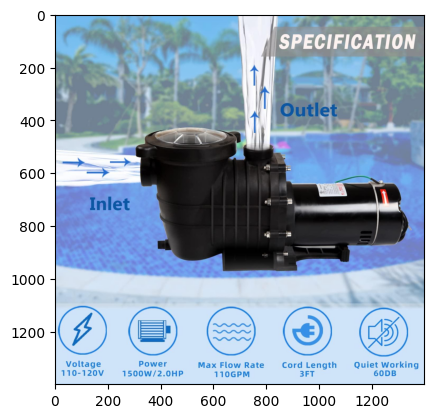

In [19]:
img = example['image']
plt.imshow(img)
plt.show()

Let’s create a method that takes the model, processor, and sample as inputs to generate the model's answer. This will allow us to streamline the inference process and easily evaluate the VLM's performance.

In [20]:
def generate_text_from_sample(model, processor, sample, max_new_tokens=32, device="cuda"):
    formatted_sample = format_data(**sample)

    message = formatted_sample[:1]
    text_input = processor.apply_chat_template(
        message,
        add_generation_prompt=True,
        tokenize=False
    )

    image_inputs = []
    # Access the image from the formatted sample (user turn)
    image = formatted_sample[0]['content'][0]['image']
    if image.mode != 'RGB':
        image = image.convert('RGB')
    image_inputs.append(image)

    # Prepare the inputs for the model
    model_inputs = processor(
        text=text_input,
        images=image_inputs,
        return_tensors="pt",
    ).to("cuda", torch.float32)  # cast inputs to float32

    # Cast model inputs to bfloat16
    for k, v in model_inputs.items():
        if isinstance(v, torch.Tensor) and v.dtype == torch.float32:
            model_inputs[k] = v.to(torch.bfloat16)


    # Generate text with the model
    generated_ids = model.generate(**model_inputs, max_new_tokens=max_new_tokens)

    # Trim the generated ids to remove the input ids
    trimmed_generated_ids = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    # Decode the output text
    output_text = processor.batch_decode(
        trimmed_generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )

    return output_text[0]  # Return the first decoded output text

In [21]:
output = generate_text_from_sample(model, processor, example)
output

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


' The voltage of this product is 110-120V.'

# 4. Fine-Tune the Model using TRL

In [11]:
from peft import LoraConfig, get_peft_model

# Configure LoRA
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=['down_proj','o_proj','k_proj','q_proj','gate_proj','up_proj','v_proj'],
    use_dora=True,
    init_lora_weights="gaussian"
)

In [22]:
# Apply PEFT model adaptation
peft_model = get_peft_model(model, peft_config)

# Print trainable parameters
peft_model.print_trainable_parameters()

trainable params: 3,067,776 || all params: 259,552,704 || trainable%: 1.1819


In [23]:
# image_token_id = processor.tokenizer.additional_special_tokens_ids[
#             processor.tokenizer.additional_special_tokens.index("<image>")]

def collate_fn(batch):
    texts, images = [], []
    for sample in batch:
        messages = format_data(sample["image"], sample["entity_name"], sample["entity_value"])
        text = processor.apply_chat_template(messages, add_generation_prompt=False)
        texts.append(text.strip())
        images.append(sample["image"])

    batch = processor(text=texts, images=images, return_tensors="pt", padding=True)
    labels = batch["input_ids"].clone()
    for i in range(len(labels)):
          idx, prev = 0, -1
          for curr in batch["input_ids"][i]:
              if curr == 9531 and prev == 9519:
                  break
              prev = curr
              idx += 1
          labels[i][:idx+2] = -100
          labels[i][labels[i] == processor.tokenizer.pad_token_id] = -100

    batch["labels"] = labels
    return batch

In [24]:
from trl import SFTConfig

output_dir = model_path + '/smolvlm_2'

# Configure training arguments using SFTConfig
training_args = SFTConfig(
    output_dir=output_dir,
    num_train_epochs=1,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    warmup_steps=7,
    learning_rate=1e-4,
    weight_decay=0.01,
    logging_steps=10,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=1,
    optim="adamw_torch_fused",
    report_to="none",
    remove_unused_columns=False,
    gradient_checkpointing=True,
    dataset_text_field="",
    dataset_kwargs={"skip_prepare_dataset": True},
)

In [28]:
from trl import SFTTrainer

trainer = SFTTrainer(
    model=peft_model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=collate_fn,
    processing_class=processor,
)

Time to Train the Model!

In [29]:
trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 49279, 'bos_token_id': 1, 'pad_token_id': 2}.


Step,Training Loss
10,3.042908
20,1.272297
30,0.886350
40,0.604040
50,0.672423
60,0.622307


TrainOutput(global_step=63, training_loss=1.1590302368951222, metrics={'train_runtime': 4863.1914, 'train_samples_per_second': 0.103, 'train_steps_per_second': 0.013, 'total_flos': 794220039440640.0, 'train_loss': 1.1590302368951222, 'entropy': 0.6668540716171265, 'num_tokens': 563366.0, 'mean_token_accuracy': 0.852762234210968, 'epoch': 1.0})

Let's save the results

In [30]:
trainer.save_model(training_args.output_dir)

# 5. Testing the Fine-Tuned Model

In [32]:
from transformers import AutoProcessor, AutoModelForImageTextToText

model_id = "HuggingFaceTB/SmolVLM-256M-Instruct"

In [33]:
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

In [34]:
from transformers import BitsAndBytesConfig

# Define the quantization config
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

In [36]:
# Load the model using the config
model = AutoModelForImageTextToText.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    device_map="auto",
)

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


In [37]:
adapter_path = model_path + '/smolvlm_2'
model.load_adapter(adapter_path)

Loading weights:   0%|          | 0/492 [00:00<?, ?it/s]

[transformers] Idefics3ForConditionalGeneration LOAD REPORT from: drive/MyDrive/Amazon ML 2024/Models/smolvlm_2
Key                                                                                              | Status     | 
-------------------------------------------------------------------------------------------------+------------+-
model.text_model.layers.{0...29}.self_attn.k_proj.lora_magnitude_vector.default                  | UNEXPECTED | 
model.text_model.layers.{0...29}.mlp.gate_proj.lora_magnitude_vector.default                     | UNEXPECTED | 
model.text_model.layers.{0...29}.mlp.up_proj.lora_magnitude_vector.default                       | UNEXPECTED | 
model.text_model.layers.{0...29}.self_attn.q_proj.lora_magnitude_vector.default                  | UNEXPECTED | 
model.text_model.layers.{0...29}.self_attn.o_proj.lora_magnitude_vector.default                  | UNEXPECTED | 
model.text_model.layers.{0...29}.self_attn.v_proj.lora_magnitude_vector.default                  

LoadStateDictInfo(missing_keys={'model.text_model.layers.8.self_attn.v_proj.lora_magnitude_vector.default.weight', 'model.text_model.layers.23.mlp.gate_proj.lora_magnitude_vector.default.weight', 'model.text_model.layers.13.self_attn.k_proj.lora_magnitude_vector.default.weight', 'model.text_model.layers.2.self_attn.q_proj.lora_magnitude_vector.default.weight', 'model.text_model.layers.5.self_attn.o_proj.lora_magnitude_vector.default.weight', 'model.text_model.layers.28.mlp.down_proj.lora_magnitude_vector.default.weight', 'model.text_model.layers.10.mlp.gate_proj.lora_magnitude_vector.default.weight', 'model.text_model.layers.8.self_attn.o_proj.lora_magnitude_vector.default.weight', 'model.text_model.layers.10.mlp.up_proj.lora_magnitude_vector.default.weight', 'model.text_model.layers.14.self_attn.o_proj.lora_magnitude_vector.default.weight', 'model.text_model.layers.1.mlp.up_proj.lora_magnitude_vector.default.weight', 'model.text_model.layers.15.mlp.up_proj.lora_magnitude_vector.defaul

In [38]:
from peft import PeftModel
model = PeftModel.from_pretrained(model, adapter_path)

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Let's evaluate the model on an unseen sample.


In [39]:
format_data(**test_dataset[40])

[{'role': 'user',
  'content': [{'type': 'image',
    'image': <PIL.Image.Image image mode=RGB size=1500x1500>},
   {'type': 'text', 'text': 'What is the item volume of this product?'}]},
 {'role': 'assistant', 'content': [{'type': 'text', 'text': '17.6 ounce'}]}]

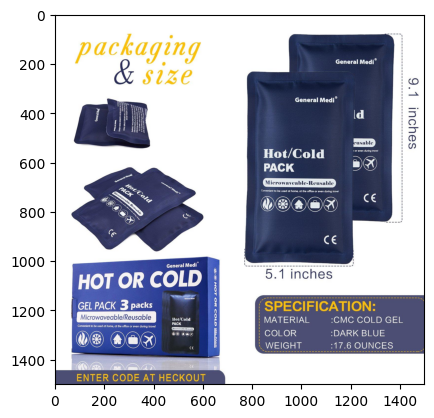

In [40]:
img = test_dataset[40]['image']
plt.imshow(img)
plt.show()

In [41]:
output = generate_text_from_sample(model, processor, test_dataset[40])
output

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


' 17.6 ounce'

In [42]:
output = generate_text_from_sample(model, processor, example)
output

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


' 110 volt'